# ShadowFox Data Analytics – Intermediate Level

## Online Retail II: Customer, Revenue & Business Performance Analysis

### Objective

To analyse customer behaviour, product performance, revenue trends, market contribution, and return patterns, and derive actionable business insights and recommendations.

## 1. Dataset Overview

The Online Retail II dataset contains transactional records of an online retail business from December 2009 to December 2011.

### Dataset Details

- Two sheets: Year 2009–2010 and Year 2010–2011
- 8 columns
- More than 1 million transaction records

### Key Columns

- Invoice – Transaction/invoice number
- StockCode – Product code
- Description – Product description
- Quantity – Number of items purchased
- InvoiceDate – Date and time of transaction
- Price – Unit price
- Customer ID – Customer identifier
- Country – Customer's country

## 2. Data Loading

The Online Retail II dataset was loaded from the Excel workbook using Python and pandas.

The dataset contains two sheets covering transactions from 2009–2010 and 2010–2011.

In [47]:
import pandas as pd
import numpy as np

file_path = "../Dataset/online_retail_II.xlsx"

df_2009_2010 = pd.read_excel(
    file_path,
    sheet_name="Year 2009-2010"
)

df_2010_2011 = pd.read_excel(
    file_path,
    sheet_name="Year 2010-2011"
)

print(df_2009_2010.shape)
print(df_2010_2011.shape)

(525461, 8)
(541910, 8)


## 3. Initial Data Exploration

In [48]:
df = pd.concat(
    [df_2009_2010, df_2010_2011],
    ignore_index=True
)

print(df.shape)

(1067371, 8)


In [49]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [50]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Duplicate rows: 34335


In [51]:
duplicate_rows = df[df.duplicated(keep=False)]

duplicate_rows.head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom


## 4. Data Cleaning and Preparation

In [52]:
df_clean = df.drop_duplicates().copy()

print("Original rows:", len(df))
print("Cleaned rows:", len(df_clean))
print("Removed duplicates:", len(df) - len(df_clean))

Original rows: 1067371
Cleaned rows: 1033036
Removed duplicates: 34335


In [53]:
print(df_clean[["Description", "Customer ID"]].isnull().sum())

print("\nCustomer ID missing rows:", df_clean["Customer ID"].isnull().sum())

print("\nRevenue-related values for missing Customer ID:")
print(df_clean.loc[df_clean["Customer ID"].isnull(), ["Quantity", "Price"]].describe())

Description      4275
Customer ID    235151
dtype: int64

Customer ID missing rows: 235151

Revenue-related values for missing Customer ID:
            Quantity          Price
count  235151.000000  235151.000000
mean        1.505628       7.705913
std       100.467469     220.242977
min     -9600.000000  -53594.360000
25%         1.000000       1.660000
50%         1.000000       3.290000
75%         2.000000       5.790000
max     10200.000000   25111.090000


In [54]:
print("Negative Quantity:", (df_clean["Quantity"] < 0).sum())
print("Zero Quantity:", (df_clean["Quantity"] == 0).sum())

print("Negative Price:", (df_clean["Price"] < 0).sum())
print("Zero Price:", (df_clean["Price"] == 0).sum())

Negative Quantity: 22496
Zero Quantity: 0
Negative Price: 5
Zero Price: 6014


In [55]:
df_clean[df_clean["Price"]<0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [56]:
df_clean = df_clean[df_clean["Price"] >= 0].copy()

print("Negative price rows remaining:", (df_clean["Price"] < 0).sum())
print("Rows after removing bad debt adjustments:", len(df_clean))

Negative price rows remaining: 0
Rows after removing bad debt adjustments: 1033031


In [57]:
zero_price = df_clean[df_clean["Price"] == 0]

print("Zero-price rows:", len(zero_price))

print("\nDescriptions:")
print(zero_price["Description"].value_counts().head(20))

Zero-price rows: 6014

Descriptions:
Description
check                            160
?                                 90
damages                           83
damaged                           81
found                             28
missing                           27
sold as set on dotcom             20
Damaged                           17
adjustment                        16
OWL DOORSTOP                      14
POLYESTER FILLER PAD 45x45cm      12
dotcom                            12
POLYESTER FILLER PAD 40x40cm      10
smashed                            9
Found                              9
FRENCH BLUE METAL DOOR SIGN 1      9
thrown away                        9
Unsaleable, destroyed.             9
PICNIC BASKET WICKER LARGE         8
checked                            8
Name: count, dtype: int64


In [58]:
df_clean = df_clean[df_clean["Price"] > 0].copy()

print("Rows after removing zero-price records:", len(df_clean))
print("Zero-price rows remaining:", (df_clean["Price"] == 0).sum())

Rows after removing zero-price records: 1027017
Zero-price rows remaining: 0


In [59]:
negative_qty = df_clean[df_clean["Quantity"] < 0]

print("Negative quantity rows:", len(negative_qty))

print("\nInvoice examples:")
print(negative_qty["Invoice"].head(20).to_list())

print("\nDescriptions:")
print(negative_qty["Description"].value_counts().head(20))

Negative quantity rows: 19103

Invoice examples:
['C489449', 'C489449', 'C489449', 'C489449', 'C489449', 'C489449', 'C489449', 'C489449', 'C489449', 'C489459', 'C489459', 'C489459', 'C489459', 'C489459', 'C489459', 'C489459', 'C489459', 'C489459', 'C489459', 'C489459']

Descriptions:
Description
Manual                                533
REGENCY CAKESTAND 3 TIER              341
POSTAGE                               228
BAKING SET 9 PIECE RETROSPOT          209
STRAWBERRY CERAMIC TRINKET BOX        181
Discount                              168
WHITE HANGING HEART T-LIGHT HOLDER    134
WHITE CHERRY LIGHTS                   121
RED RETROSPOT CAKE STAND              107
SAMPLES                                98
JAM MAKING SET WITH JARS               87
PINK CHERRY LIGHTS                     86
WOOD 2 DRAWER CABINET WHITE FINISH     85
SWEETHEART CERAMIC TRINKET BOX         73
SET OF 3 CAKE TINS PANTRY DESIGN       73
JUMBO BAG RED RETROSPOT                72
CERAMIC CAKE STAND + HANGING CA

In [60]:
negative_qty = df_clean[df_clean["Quantity"] < 0].copy()

print("Negative quantity rows:", len(negative_qty))

print(
    "Negative quantity rows with C invoice:",
    negative_qty["Invoice"].astype(str).str.startswith("C").sum()
)

print(
    "Negative quantity rows without C invoice:",
    (~negative_qty["Invoice"].astype(str).str.startswith("C")).sum()
)

Negative quantity rows: 19103
Negative quantity rows with C invoice: 19103
Negative quantity rows without C invoice: 0


In [61]:
returns_df = df_clean[df_clean["Invoice"].astype(str).str.startswith("C")].copy()

sales_df = df_clean[df_clean["Quantity"] > 0].copy()

print("Returns/Cancelled rows:", len(returns_df))
print("Normal sales rows:", len(sales_df))

Returns/Cancelled rows: 19104
Normal sales rows: 1007914


## 5. Revenue Analysis

In [62]:
sales_df["Revenue"] = sales_df["Quantity"] * sales_df["Price"]

returns_df["Return_Value"] = (
    returns_df["Quantity"].abs() * returns_df["Price"]
)

print(sales_df[["Quantity", "Price", "Revenue"]].head())
print("\nTotal Sales Revenue:", sales_df["Revenue"].sum())
print("Total Return Value:", returns_df["Return_Value"].sum())

   Quantity  Price  Revenue
0        12   6.95     83.4
1        12   6.75     81.0
2        12   6.75     81.0
3        48   2.10    100.8
4        24   1.25     30.0

Total Sales Revenue: 20476634.018
Total Return Value: 1462797.7500000002


In [63]:
total_sales = sales_df["Revenue"].sum()
total_returns = returns_df["Return_Value"].sum()

net_revenue = total_sales - total_returns

print("Total Sales Revenue:", total_sales)
print("Total Return Value:", total_returns)
print("Net Revenue:", net_revenue)

Total Sales Revenue: 20476634.018
Total Return Value: 1462797.7500000002
Net Revenue: 19013836.268


In [64]:
print(sales_df["InvoiceDate"].dtype)
print(sales_df["InvoiceDate"].min())
print(sales_df["InvoiceDate"].max())

datetime64[us]
2009-12-01 07:45:00
2011-12-09 12:50:00


In [65]:
print(sales_df["Customer ID"].dtype)
print("Unique customers:", sales_df["Customer ID"].nunique())
print("Missing Customer IDs:", sales_df["Customer ID"].isnull().sum())

float64
Unique customers: 5878
Missing Customer IDs: 228489


## 6. Customer Analysis

In [66]:
customer_sales = sales_df[sales_df["Customer ID"].notna()].copy()

print("Customer analysis rows:", len(customer_sales))
print("Unique customers:", customer_sales["Customer ID"].nunique())
print("Missing Customer IDs:", customer_sales["Customer ID"].isnull().sum())

Customer analysis rows: 779425
Unique customers: 5878
Missing Customer IDs: 0


In [67]:
top_customers = (
    customer_sales.groupby("Customer ID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_customers)

Customer ID
18102.0    580987.04
14646.0    528602.52
14156.0    313437.62
14911.0    291420.81
17450.0    244784.25
13694.0    195640.69
17511.0    172132.87
16446.0    168472.50
16684.0    147142.77
12415.0    144458.37
Name: Revenue, dtype: float64


In [68]:
top_10_revenue = top_customers.sum()
total_customer_revenue = customer_sales["Revenue"].sum()

top_10_percentage = (top_10_revenue / total_customer_revenue) * 100

print("Top 10 Customer Revenue:", top_10_revenue)
print("Total Customer Revenue:", total_customer_revenue)
print("Top 10 Contribution:", top_10_percentage, "%")

Top 10 Customer Revenue: 2787079.44
Total Customer Revenue: 17374804.268
Top 10 Contribution: 16.040925681868522 %


In [69]:
customer_orders = (
    customer_sales.groupby("Customer ID")["Invoice"]
    .nunique()
)

print(customer_orders.describe())

count    5878.000000
mean        6.289384
std        13.009406
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       398.000000
Name: Invoice, dtype: float64


In [70]:
one_time_customers = (customer_orders == 1).sum()
repeat_customers = (customer_orders > 1).sum()

print("One-time customers:", one_time_customers)
print("Repeat customers:", repeat_customers)

print(
    "Repeat customer percentage:",
    (repeat_customers / len(customer_orders)) * 100
)

One-time customers: 1623
Repeat customers: 4255
Repeat customer percentage: 72.38856753997959


## 7. Product Analysis

In [71]:
top_products_revenue = (
    sales_df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products_revenue)

Description
Manual                                339614.86
REGENCY CAKESTAND 3 TIER              330590.32
DOTCOM POSTAGE                        309854.11
WHITE HANGING HEART T-LIGHT HOLDER    260990.22
PAPER CRAFT , LITTLE BIRDIE           168469.60
PARTY BUNTING                         148318.28
JUMBO BAG RED RETROSPOT               148073.47
ASSORTED COLOUR BIRD ORNAMENT         129324.49
POSTAGE                               125682.42
PAPER CHAIN KIT 50'S CHRISTMAS        117760.29
Name: Revenue, dtype: float64


In [72]:
product_sales = sales_df[
    ~sales_df["Description"].str.upper().str.contains(
        "POSTAGE|MANUAL|DISCOUNT|DOTCOM", na=False
    )
].copy()

top_real_products = (
    product_sales.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_real_products)

Description
REGENCY CAKESTAND 3 TIER               330590.32
WHITE HANGING HEART T-LIGHT HOLDER     260990.22
PAPER CRAFT , LITTLE BIRDIE            168469.60
PARTY BUNTING                          148318.28
JUMBO BAG RED RETROSPOT                148073.47
ASSORTED COLOUR BIRD ORNAMENT          129324.49
PAPER CHAIN KIT 50'S CHRISTMAS         117760.29
MEDIUM CERAMIC TOP STORAGE JAR          81700.92
CHILLI LIGHTS                           80540.88
ROTATING SILVER ANGELS T-LIGHT HLDR     71300.40
Name: Revenue, dtype: float64


In [73]:
top_products_quantity = (
    product_sales.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products_quantity)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     106139
WHITE HANGING HEART T-LIGHT HOLDER     94658
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          80082
MEDIUM CERAMIC TOP STORAGE JAR         78033
JUMBO BAG RED RETROSPOT                77699
BROCADE RING PURSE                     70369
PACK OF 60 PINK PAISLEY CAKE CASES     56061
60 TEATIME FAIRY CAKE CASES            54028
SMALL POPCORN HOLDER                   48561
Name: Quantity, dtype: int64


In [74]:
sales_df["YearMonth"]=sales_df["InvoiceDate"].dt.to_period("M")
monthly_revenue=(sales_df.groupby("YearMonth")["Revenue"].sum())
print(monthly_revenue)

YearMonth
2009-12     822483.950
2010-01     651155.112
2010-02     551878.296
2010-03     830915.261
2010-04     678875.252
2010-05     657705.500
2010-06     749537.310
2010-07     648810.270
2010-08     695251.910
2010-09     921696.991
2010-10    1161902.220
2010-11    1464293.142
2010-12     821452.730
2011-01     689811.610
2011-02     522545.560
2011-03     716215.260
2011-04     536968.491
2011-05     769296.610
2011-06     760547.010
2011-07     718076.121
2011-08     757841.380
2011-09    1056435.192
2011-10    1151263.730
2011-11    1503866.780
2011-12     637808.330
Freq: M, Name: Revenue, dtype: float64


## 8. Trend Analysis

In [75]:
returns_df["YearMonth"] = returns_df["InvoiceDate"].dt.to_period("M")

monthly_returns = (
    returns_df.groupby("YearMonth")["Return_Value"]
    .sum()
)

print(monthly_returns)

YearMonth
2009-12     25835.45
2010-01     28675.61
2010-02     20986.50
2010-03     67668.02
2010-04     37354.20
2010-05     44434.78
2010-06     72463.44
2010-07     31444.79
2010-08     40477.52
2010-09     70591.03
2010-10     81290.74
2010-11     47595.94
2010-12     74729.12
2011-01    131363.05
2011-02     25519.15
2011-03     34201.28
2011-04     44600.65
2011-05     47202.51
2011-06     70569.78
2011-07     37919.13
2011-08     54330.80
2011-09     38838.51
2011-10     81895.50
2011-11     47720.98
2011-12    205089.27
Freq: M, Name: Return_Value, dtype: float64


In [76]:
monthly_sales = sales_df.groupby("YearMonth")["Revenue"].sum()

monthly_return_rate = (
    monthly_returns / monthly_sales * 100
).fillna(0)

print(monthly_return_rate)

YearMonth
2009-12     3.141149
2010-01     4.403806
2010-02     3.802741
2010-03     8.143793
2010-04     5.502366
2010-05     6.756030
2010-06     9.667756
2010-07     4.846531
2010-08     5.821993
2010-09     7.658811
2010-10     6.996349
2010-11     3.250438
2010-12     9.097191
2011-01    19.043323
2011-02     4.883622
2011-03     4.775279
2011-04     8.306009
2011-05     6.135801
2011-06     9.278819
2011-07     5.280656
2011-08     7.169152
2011-09     3.676374
2011-10     7.113531
2011-11     3.173219
2011-12    32.155314
Freq: M, dtype: float64


In [77]:
top_return_products = (
    returns_df[returns_df["Description"].notna()]
    .groupby("Description")["Return_Value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_return_products)

Description
Manual                                423299.71
AMAZON FEE                            241988.30
PAPER CRAFT , LITTLE BIRDIE           168469.60
MEDIUM CERAMIC TOP STORAGE JAR         77479.64
Bank Charges                           33902.53
REGENCY CAKESTAND 3 TIER               16545.30
POSTAGE                                15252.01
Discount                               13277.52
WHITE HANGING HEART T-LIGHT HOLDER      9387.10
CRUK Commission                         7933.43
Name: Return_Value, dtype: float64


In [78]:
return_product_data = returns_df[
    ~returns_df["Description"].str.upper().str.contains(
        "MANUAL|AMAZON FEE|BANK CHARGES|POSTAGE|DISCOUNT|COMMISSION",
        na=False
    )
].copy()

top_real_return_products = (
    return_product_data.groupby("Description")["Return_Value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_real_return_products)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
MEDIUM CERAMIC TOP STORAGE JAR         77479.64
REGENCY CAKESTAND 3 TIER               16545.30
WHITE HANGING HEART T-LIGHT HOLDER      9387.10
COLOUR GLASS. STAR T-LIGHT HOLDER       6966.66
FAIRY CAKE FLANNEL ASSORTED COLOUR      6614.37
WHITE CHERRY LIGHTS                     6331.30
SAMPLES                                 6127.96
SET/4 WHITE RETRO STORAGE CUBES         5187.65
PANTRY CHOPPING BOARD                   4803.06
Name: Return_Value, dtype: float64


In [79]:
product_sales_revenue = (
    product_sales.groupby("Description")["Revenue"]
    .sum()
)

product_return_value = (
    return_product_data.groupby("Description")["Return_Value"]
    .sum()
)

product_return_rate = (
    product_return_value / product_sales_revenue * 100
).dropna().sort_values(ascending=False)

print(product_return_rate.head(15))

Description
PADS TO MATCH ALL CUSHIONS             215294.117647
SAMPLES                                  4477.866277
WHITE SCANDINAVIAN HEART CHRISTMAS       1200.000000
FEATHER HEART LIGHTS                      777.966102
RED HEART CANDY POP LIGHTS                300.000000
TREE OF NOAH FESTIVE SCENTED CANDLE       297.345133
SILVER CHERRY LIGHTS                      267.896710
S/16 BLACK SHINY/MAT BAUBLES              240.000000
CREAM SWEETHEART DOUBLE SHELF             200.000000
CERAMIC CAKE TEAPOT WITH CHERRY           171.717172
KISS REINDEER SCANDINAVIAN STOCKING       120.000000
WHITE CHERRY LIGHTS                       108.226240
BREAD BIN DINER STYLE BLACK               100.000000
BOX OF 3 PEBBLE CANDLES                   100.000000
WOODLAND CREATURES  WRAP                  100.000000
dtype: float64


In [80]:
valid_product_return_rate = product_return_rate[
    product_sales_revenue >= 1000
].sort_values(ascending=False)

print(valid_product_return_rate.head(15))

Description
WHITE CHERRY LIGHTS                  108.226240
PAPER CRAFT , LITTLE BIRDIE          100.000000
BLACK CHERRY LIGHTS                   99.457112
MEDIUM CERAMIC TOP STORAGE JAR        94.833253
PANTRY CHOPPING BOARD                 81.844764
PINK FAIRY CAKE COASTER               78.554024
FLOWERS CHANDELIER T-LIGHT HOLDER     64.565165
WILLOW BRANCH LIGHTS.                 56.956975
SMALL FAIRY CAKE FRIDGE MAGNETS       53.027636
GOLD  CHERRY LIGHTS                   51.668924
IVORY CHANDELIER T-LIGHT HOLDER       49.507590
BLUE CUSHION COVER WITH FLOWER        46.805950
BEADED CHANDELIER T-LIGHT HOLDER      44.768714
CALENDAR FAMILY FAVOURITES            44.111160
SET 4 NURSERY DES ROUND BOXES         43.775353
dtype: float64


In [81]:
customer_revenue = (
    customer_sales.groupby("Customer ID")["Revenue"]
    .sum()
)

print(customer_revenue.describe())

count      5878.000000
mean       2955.904095
std       14440.852688
min           2.950000
25%         342.280000
50%         867.740000
75%        2248.305000
max      580987.040000
Name: Revenue, dtype: float64


In [82]:
q25 = customer_revenue.quantile(0.25)
q75 = customer_revenue.quantile(0.75)

customer_segment = pd.cut(
    customer_revenue,
    bins=[-float("inf"), q25, q75, float("inf")],
    labels=["Low Value", "Mid Value", "High Value"]
)

print("Q25:", q25)
print("Q75:", q75)
print("\nCustomer Segment Counts:")
print(customer_segment.value_counts())

print("\nRevenue by Segment:")
print(
    customer_revenue.groupby(customer_segment, observed=True).sum()
)

Q25: 342.28
Q75: 2248.305

Customer Segment Counts:
Revenue
Mid Value     2938
Low Value     1470
High Value    1470
Name: count, dtype: int64

Revenue by Segment:
Revenue
Low Value     2.829879e+05
Mid Value     2.915044e+06
High Value    1.417677e+07
Name: Revenue, dtype: float64


In [83]:
customer_order_counts = customer_sales.groupby("Customer ID")["Invoice"].nunique()

segment_orders = (
    customer_order_counts.groupby(customer_segment)
    .sum()
)

print(segment_orders)

Revenue
Low Value      1918
Mid Value     10683
High Value    24368
Name: Invoice, dtype: int64


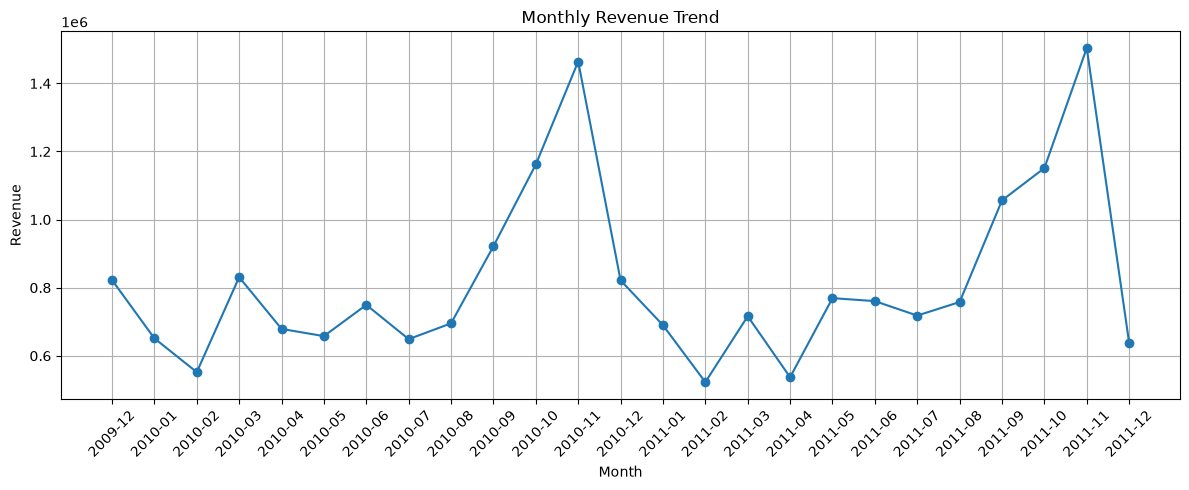

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

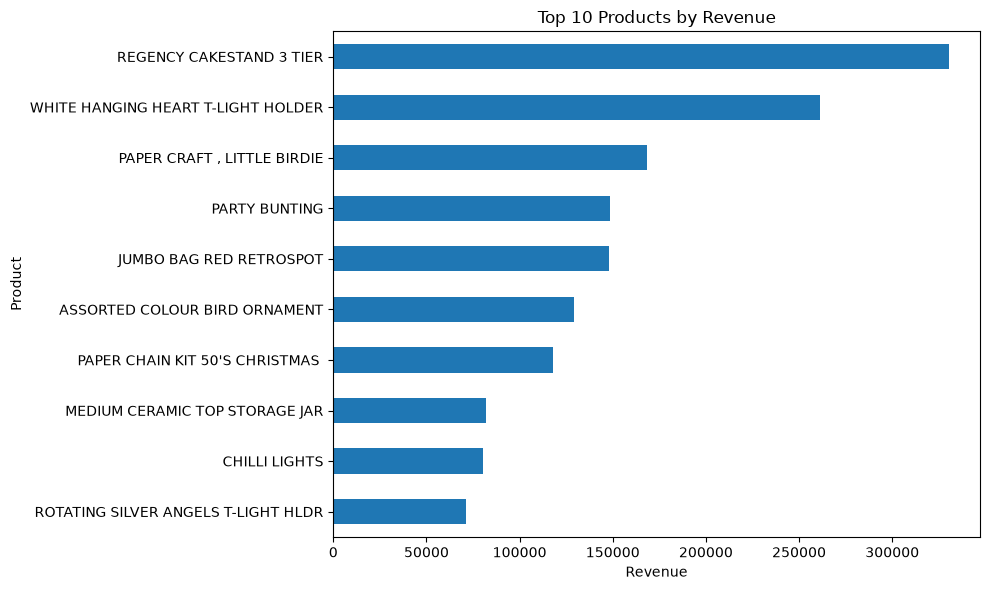

In [85]:
# Remove non-product/operational transactions
excluded_items = [
    "Manual",
    "DOTCOM POSTAGE",
    "POSTAGE",
    "AMAZON FEE",
    "BANK CHARGES",
    "DISCOUNT",
    "CRUK COMMISSION"
]

actual_product_sales = sales_df[
    ~sales_df["Description"].str.upper().isin(
        [x.upper() for x in excluded_items]
    )
]

top_products_revenue = (
    actual_product_sales
    .groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

top_products_revenue.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()

plt.show()

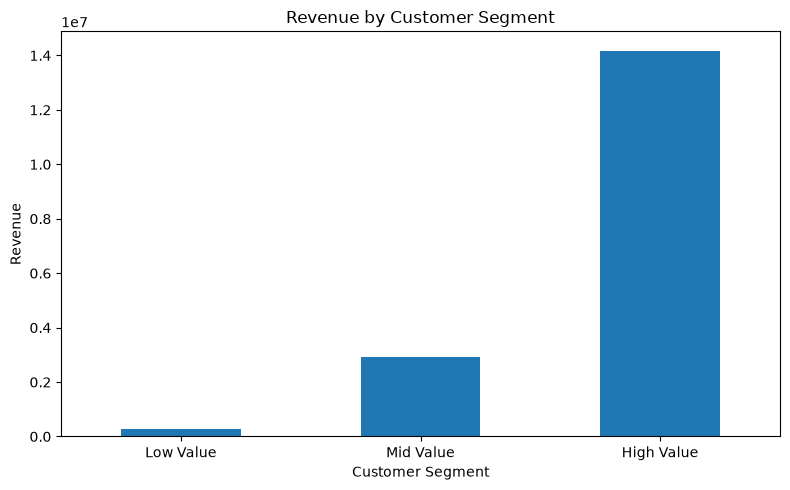

In [86]:
segment_revenue = (
    customer_revenue.groupby(customer_segment, observed=True)
    .sum()
)

plt.figure(figsize=(8, 5))

segment_revenue.plot(kind="bar")

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

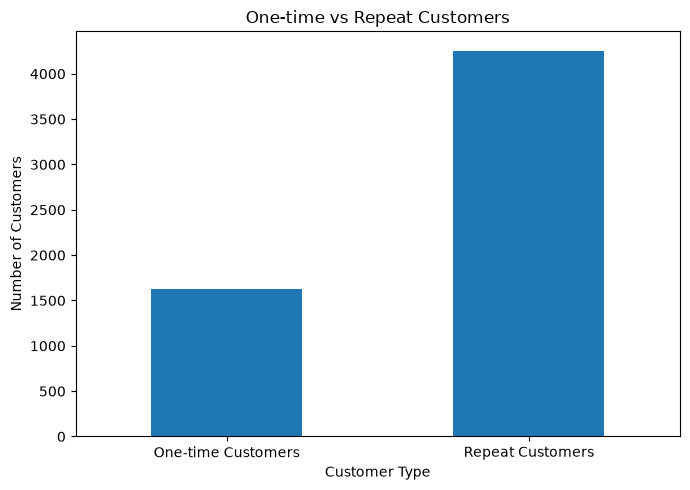

In [87]:
customer_type = pd.Series(
    {
        "One-time Customers": one_time_customers,
        "Repeat Customers": repeat_customers
    }
)

plt.figure(figsize=(7, 5))

customer_type.plot(kind="bar")

plt.title("One-time vs Repeat Customers")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

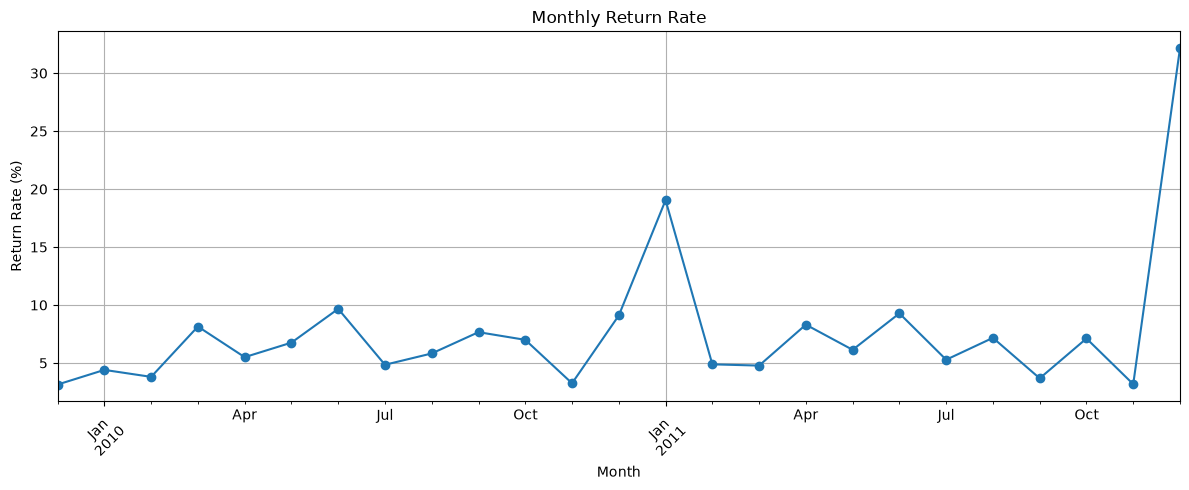

In [88]:
plt.figure(figsize=(12, 5))

monthly_return_rate.plot(kind="line", marker="o")

plt.title("Monthly Return Rate")
plt.xlabel("Month")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

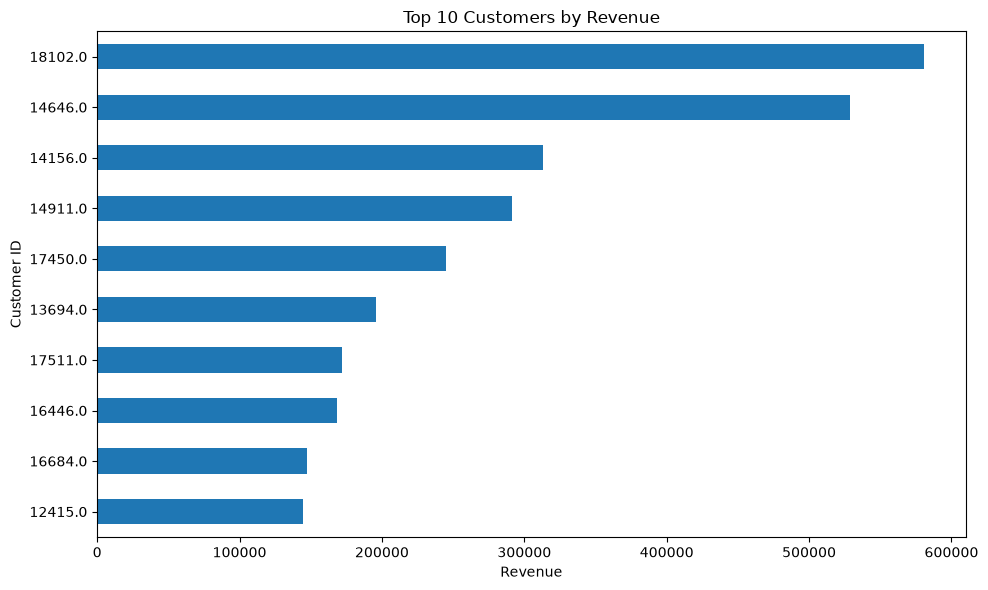

In [89]:
top_customers = (
    customer_revenue
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

top_customers.sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")
plt.tight_layout()

plt.show()

## 9. Geographic Analysis

In [90]:
country_revenue = (
    sales_df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(country_revenue.head(15))

Country
United Kingdom     1.741057e+07
EIRE               6.587673e+05
Netherlands        5.540381e+05
Germany            4.250197e+05
France             3.504561e+05
Australia          1.692835e+05
Spain              1.083325e+05
Switzerland        1.006856e+05
Sweden             9.186982e+04
Denmark            6.858069e+04
Belgium            6.538782e+04
Norway             5.632250e+04
Portugal           5.628353e+04
Channel Islands    4.462333e+04
Japan              4.302391e+04
Name: Revenue, dtype: float64


In [91]:
uk_revenue = country_revenue["United Kingdom"]
total_revenue = sales_df["Revenue"].sum()

uk_percentage = (uk_revenue / total_revenue) * 100

print("UK Revenue:", uk_revenue)
print("Total Revenue:", total_revenue)
print("UK Revenue Contribution:", uk_percentage, "%")

UK Revenue: 17410569.687
Total Revenue: 20476634.018
UK Revenue Contribution: 85.02652179892078 %


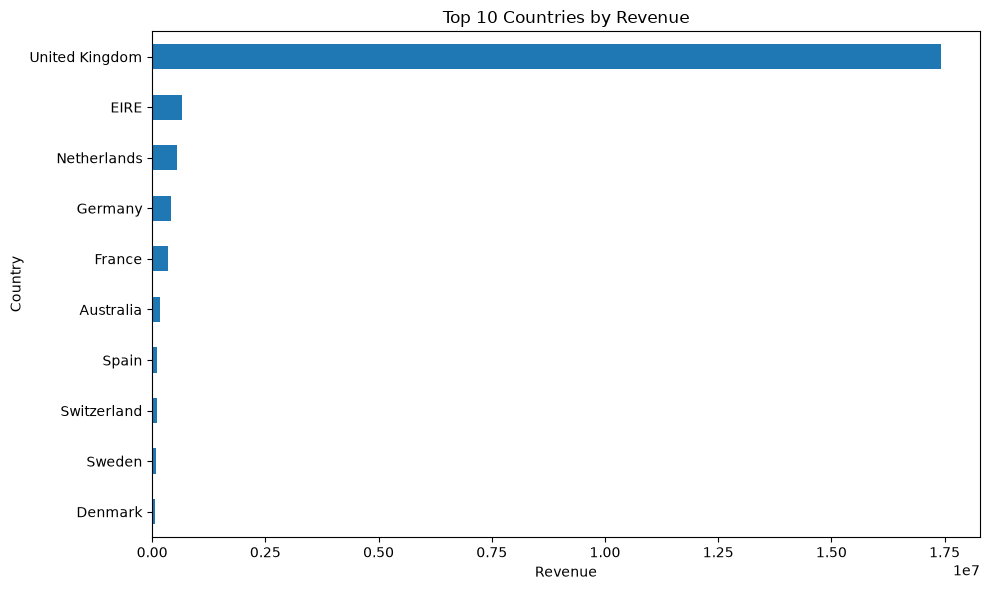

In [92]:
top_countries = (
    country_revenue
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

top_countries.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.tight_layout()

plt.show()

## 10. Key Insights and Business Recommendations

### Key Insights

- 72.39% of identified customers are repeat customers, indicating strong repeat-purchase behaviour.
- High-value customers represent 25% of customers but contribute approximately 81.6% of customer revenue.
- The United Kingdom contributes approximately 85.03% of total revenue, making it the dominant market.
- Revenue shows strong performance during September–November, with November recording particularly high revenue.
- A small number of products contribute significantly to overall revenue.
- Return rates vary considerably across months, with December 2011 showing the highest return rate.

### Business Recommendations

- Focus on retaining high-value customers through loyalty programs and personalized offers.
- Use targeted re-engagement campaigns to convert one-time customers into repeat customers.
- Maintain sufficient stock for consistently high-performing products.
- Investigate products and periods with unusually high return rates.
- Explore international markets to reduce dependence on the UK market.
- Plan inventory and marketing campaigns ahead of strong sales periods.

## 11. Conclusion

This analysis provided a deeper understanding of customer behaviour, revenue performance, product contribution, sales trends, geographic performance, and return patterns.

The findings show strong repeat-customer activity, significant revenue concentration among high-value customers, and heavy dependence on the United Kingdom market. The analysis also identified important sales and return trends that can support better customer retention, inventory planning, and business decision-making.